In [41]:
#Librerias
import csv
import matplotlib.pyplot as plt
import numpy as np
import os

In [42]:
#carga_de_datos
def cargar_datos_csv_listas(ruta_archivo):
    FSC_A = [] ;     SSC_A = [] ;    FL1_A = [] ;    FL2_A = [];     FL3_A = [] ;     FL4_A = []
    FSC_H = [];    SSC_H = [];    FL1_H = [];    FL2_H = [];    FL3_H = [];    FL4_H = []
    
    Width = [];    Time = []
    
    with open(ruta_archivo, newline='') as archivo:  #
        lector = csv.reader(archivo)
        next(lector)  
        
        for fila in lector:
            FSC_A.append(int(fila[0]))
            SSC_A.append(int(fila[1]))
            FL1_A.append(int(fila[2]))
            FL2_A.append(int(fila[3]))
            FL3_A.append(int(fila[4]))
            FL4_A.append(int(fila[5]))
            FSC_H.append(int(fila[6]))
            SSC_H.append(int(fila[7]))
            FL1_H.append(int(fila[8]))
            FL2_H.append(int(fila[9]))
            FL3_H.append(int(fila[10]))
            FL4_H.append(int(fila[11]))
            Width.append(int(fila[12]))
            Time.append(int(fila[13]))
    
    return (FSC_A, SSC_A, FL1_A, FL2_A, FL3_A, FL4_A,
            FSC_H, SSC_H, FL1_H, FL2_H, FL3_H, FL4_H,
            Width, Time)

In [43]:
colores = {
    'glucosa': '#480058',
    'glicerol_etanol': '#4B75FF',
    'glicerol': '#FFA213',
    'glucosa_etanol': '#B72818'
}

estilos = {
    'glucosa': '-.',
    'glicerol_etanol': ':',
    'glicerol': '-',
    'glucosa_etanol': '--'
}

In [ ]:
def grafica_simple(datos_dict, nombre_base):
    """
    Genera y guarda dos gráficas (scatter e histograma) en la carpeta del script.
    
    Parámetros:
    datos_dict : dict
        Diccionario con los datos de las muestras.
    nombre_base : str
        Nombre base para los archivos (sin extensión). Ej: 'resultado'
    """
    # Obtener la carpeta donde se encuentra este código
    try:
        script_dir = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        script_dir = os.getcwd()
    
    # Construir rutas completas
    save_path_scatter = os.path.join(script_dir, f"{nombre_base}_scatter.png")
    save_path_hist = os.path.join(script_dir, f"{nombre_base}_histogram.png")
    
    # ---------- FIGURA 1: Scatter (2x2) ----------
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()
    
    for i, (nombre, datos) in enumerate(datos_dict.items()):
        FL1_A, FSC_H, SSC_H = datos
        ax = axes[i]
        mask = (np.array(FSC_H) > 0) & (np.array(SSC_H) > 0)
        fsc_filtered = np.array(FSC_H)[mask]
        ssc_filtered = np.array(SSC_H)[mask]
        n_celulas = len(fsc_filtered)
        ax.scatter(fsc_filtered, ssc_filtered, s=0.2, alpha=1, c=colores.get(nombre, 'blue'), marker='.')
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_title(f"Medio: {nombre.upper()}\n(n = {n_celulas:,} células)", fontsize=13, fontweight='bold', pad=10)
        ax.set_xlabel('FSC-H (Tamaño)', fontsize=10)
        ax.set_ylabel('SSC-H (Granularidad)', fontsize=10)
        ax.grid(True, alpha=0.2, which='both')
    
    plt.tight_layout()
    fig.savefig(save_path_scatter, dpi=300, bbox_inches='tight')
    print(f"Scatter guardado: {save_path_scatter}")
    
    # ---------- FIGURA 2: Histograma con zoom ----------
    fig2, ax_main = plt.subplots(figsize=(12, 8))
    ax_zoom = fig2.add_axes([0.5, 0.2, 0.35, 0.4])
    
    for nombre, (FL1_A, FSC_H, SSC_H) in datos_dict.items():
        datos_array = np.array([x for x in FL1_A if x > 0])
        datos_zoom = datos_array[datos_array > 1500]
        n_total = len(datos_array)
        n_corte = len(datos_zoom)
        color_f = colores.get(nombre, 'blue')
        ax_main.hist(datos_array, bins=150, color=color_f, alpha=0.2, edgecolor=color_f, linewidth=1.5,
                     label=f"{nombre.upper()} (n={n_total:,})", histtype='stepfilled')
        ax_zoom.hist(datos_zoom, bins=80, color=color_f, alpha=0.7, edgecolor=color_f, linewidth=2,
                     label=f"n={n_corte:,}", histtype='stepfilled')
    
    ax_main.set_xlabel('FL1-A (Área de fluorescencia)', fontsize=12, fontweight='bold')
    ax_main.set_ylabel('Conteo de Partículas', fontsize=12, fontweight='bold')
    ax_main.set_title('Análisis de Poblaciones Totales', fontsize=15, pad=20)
    ax_main.legend(loc='upper right', title="Medios (Total)", title_fontproperties={'weight':'bold'})
    ax_main.set_xlim(-2500, 50000)
    ax_main.grid(True, alpha=0.3)
    
    ax_zoom.set_title('Población más Luminiscentes (>1500)', fontsize=11, color='black', fontweight='bold')
    ax_zoom.set_xlim(1500, 45000)
    ax_zoom.legend(loc='upper right', fontsize=8, title="n post-corte")
    ax_zoom.grid(True, alpha=0.2)
    ax_zoom.tick_params(labelsize=8)
    
    fig2.savefig(save_path_hist, dpi=300, bbox_inches='tight')
    print(f"Histograma guardado: {save_path_hist}")
    
    plt.show()

Scatter guardado: c:\Users\Administrador\Desktop\Proyecto-Experimental\Datos\DatosControl_scatter.png
Histograma guardado: c:\Users\Administrador\Desktop\Proyecto-Experimental\Datos\DatosControl_histogram.png


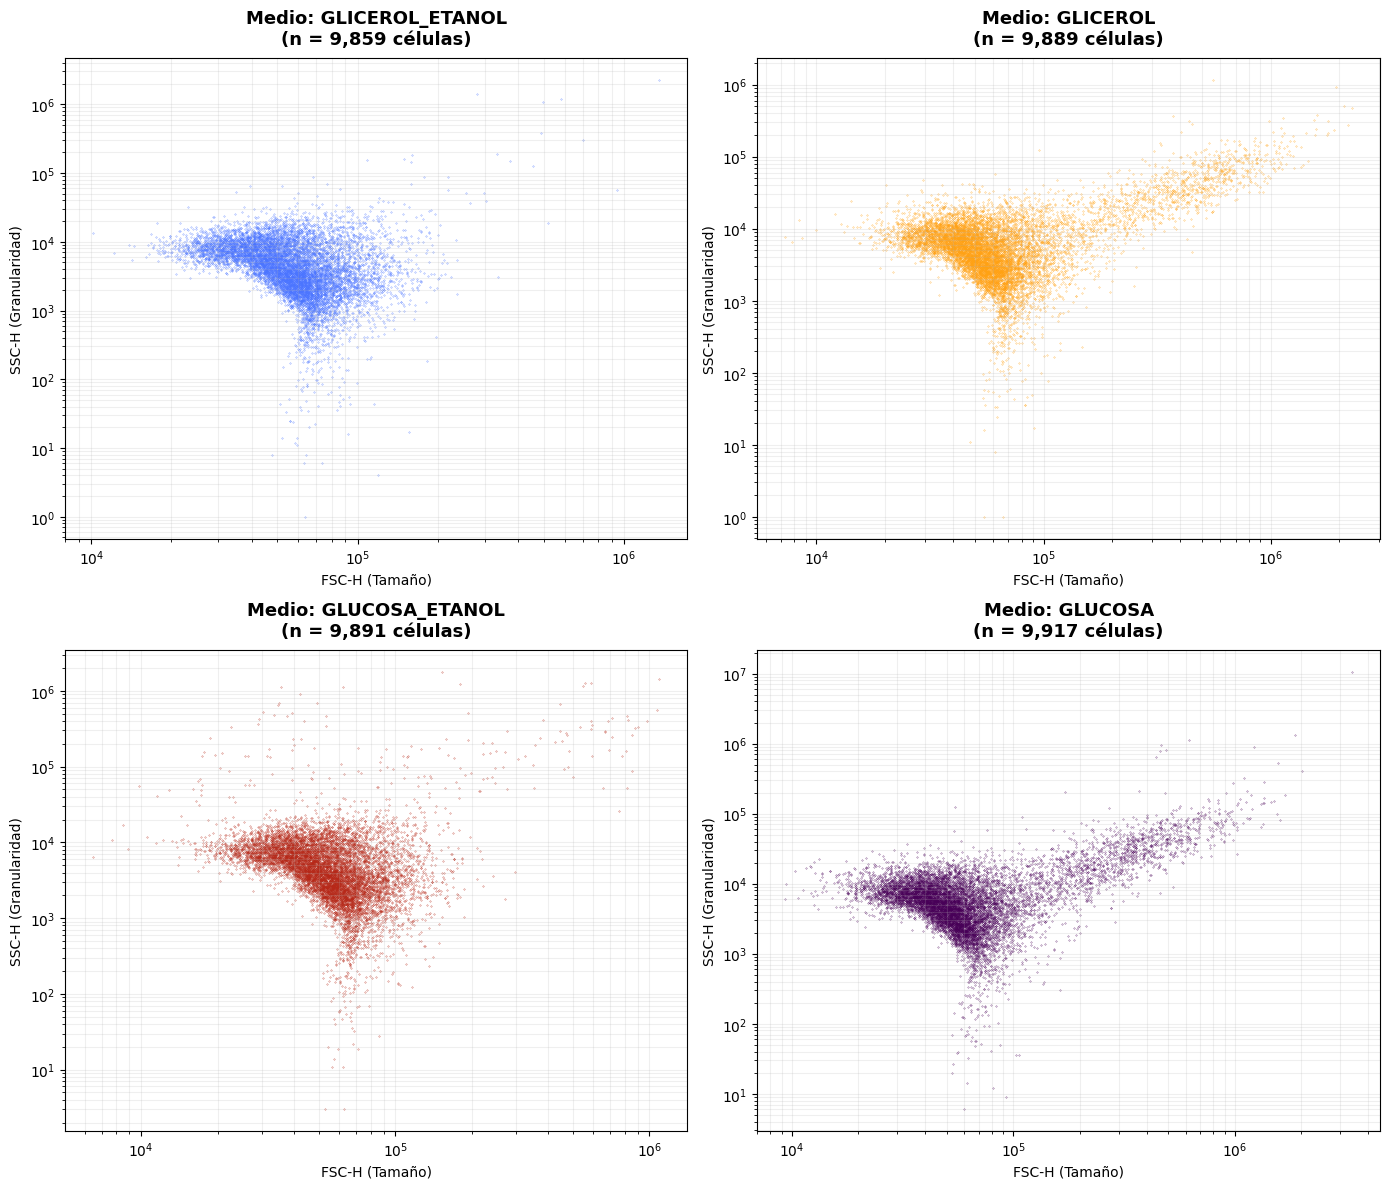

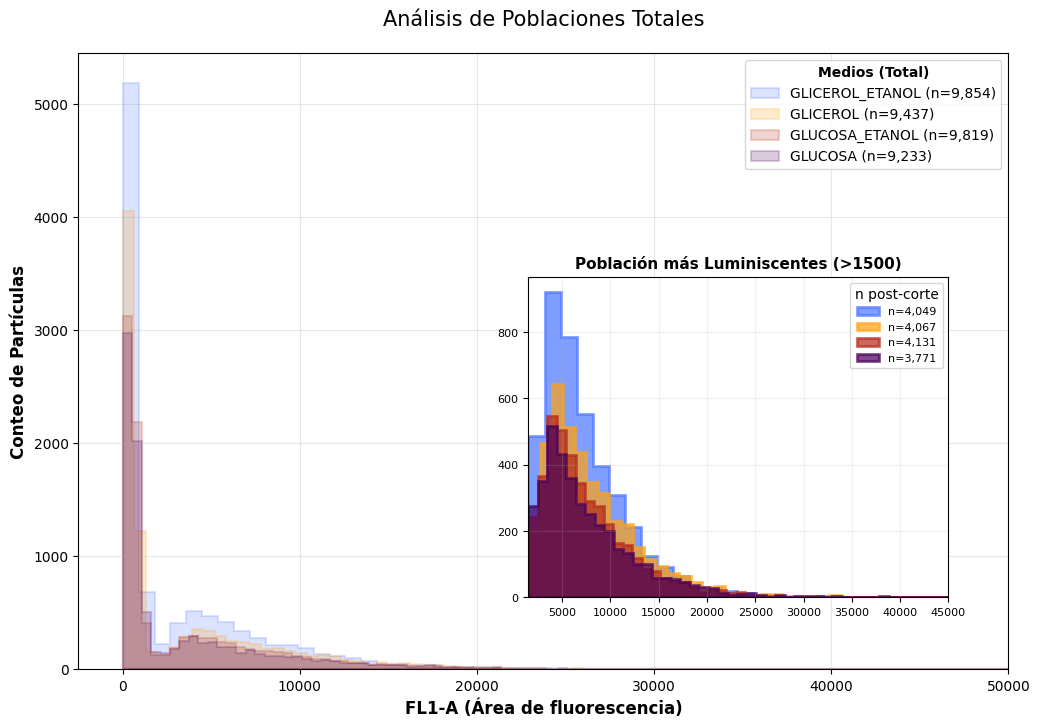

In [45]:
glicerol = cargar_datos_csv_listas('Citometro/Erol.csv')
glicerol_etanol = cargar_datos_csv_listas('Citometro/Erolol.csv')
glucosa = cargar_datos_csv_listas('Citometro/Osa.csv')
glucosa_etanol = cargar_datos_csv_listas('Citometro/Osaol.csv')


# Crear diccionario con los datos
datos_muestras = {
    
    'glicerol_etanol': (glicerol_etanol[2], glicerol_etanol[6], glicerol_etanol[1]),
    'glicerol': (glicerol[2], glicerol[6], glicerol[1]),
    'glucosa_etanol': (glucosa_etanol[2], glucosa_etanol[6], glucosa_etanol[1]),  
    'glucosa': (glucosa[2], glucosa[6], glucosa[1]),
    
}

grafica_simple(datos_muestras, "DatosControl")